In [1]:
import pandas as pd
import numpy as np

### load data

In [2]:
aapl = pd.read_csv('AAPL_2023-11_2024-11.csv')
aapl

,timestamp,volume,open,close,high,low,Volatility,depth,symbol,bid_px_00,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
0,2023-11-09 13:30:00+00:00,425,182.4900,182.4900,182.49,182.4900,NaN,0,AAPL,182.35,...,182.67,1,182.69,90,182.72,15,182.73,1,182.78,2
1,2023-11-09 13:32:00+00:00,1821,182.3500,182.3000,182.35,182.3000,NaN,9,AAPL,182.35,...,182.65,103,182.67,1,182.69,90,182.72,15,182.73,3
2,2023-11-09 13:33:00+00:00,4082,182.2602,182.2500,182.30,182.2500,NaN,1,AAPL,182.26,...,182.54,50,182.59,4,182.60,107,182.65,103,182.67,1
3,2023-11-09 13:34:00+00:00,2641,182.2300,182.2900,182.29,182.2300,NaN,7,AAPL,182.21,...,182.59,4,182.60,107,182.65,103,182.67,1,182.69,90
4,2023-11-09 13:35:00+00:00,5440,182.3000,182.3100,182.31,182.2900,NaN,2,AAPL,182.28,...,182.54,50,182.59,4,182.60,107,182.65,103,182.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103392,2024-11-08 19:56:00+00:00,26591,227.4535,227.4500,227.49,227.4301,0.072883,9,AAPL,228.09,...,228.16,245,228.17,668,228.18,313,228.19,1459,228.20,397
103393,2024-11-08 19:57:00+00:00,23227,227.4400,227.4450,227.45,227.4200,0.073030,9,AAPL,227.92,...,228.00,253,228.01,226,228.02,283,228.03,467,228.04,454
103394,2024-11-08 19:58:00+00:00,23071,227.4450,227.4600,227.48,227.4300,0.073246,9,AAPL,227.90,...,227.96,335,227.97,157,227.98,352,227.99,173,228.00,446
103395,2024-11-08 19:59:00+00:00,25473,227.4600,227.4400,227.47,227.4400,0.074191,9,AAPL,227.84,...,227.90,131,227.91,140,227.92,516,227.93,152,227.94,298


In [3]:
data = aapl[aapl.timestamp.str.contains('2024-11-08')].set_index('timestamp',drop=True)
data.index = pd.to_datetime(data.index)
data

,volume,open,close,high,low,Volatility,depth,symbol,bid_px_00,bid_sz_00,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-11-08 14:30:00+00:00,770880,227.1700,227.6400,227.7600,227.1400,0.167021,5,AAPL,227.72,483,...,229.80,1000,229.90,10,230.00,28,230.78,6,230.80,8
2024-11-08 14:31:00+00:00,237773,227.6400,228.1401,228.1700,227.4700,0.179580,4,AAPL,227.72,240,...,229.70,111,229.80,1000,229.90,10,230.00,28,230.78,6
2024-11-08 14:32:00+00:00,221508,228.1700,228.4501,228.4594,228.0700,0.241811,4,AAPL,227.72,240,...,229.70,111,229.80,1000,229.90,10,230.00,28,230.78,6
2024-11-08 14:33:00+00:00,192968,228.4600,228.3800,228.6600,228.3700,0.318099,4,AAPL,227.72,240,...,229.70,111,229.80,1000,229.90,10,230.00,28,230.78,6
2024-11-08 14:34:00+00:00,155137,228.3700,228.1250,228.3800,228.0000,0.339953,7,AAPL,227.75,441,...,229.80,1000,229.90,10,230.00,128,230.78,6,230.80,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-08 19:56:00+00:00,26591,227.4535,227.4500,227.4900,227.4301,0.072883,9,AAPL,228.09,302,...,228.16,245,228.17,668,228.18,313,228.19,1459,228.20,397
2024-11-08 19:57:00+00:00,23227,227.4400,227.4450,227.4500,227.4200,0.073030,9,AAPL,227.92,181,...,228.00,253,228.01,226,228.02,283,228.03,467,228.04,454
2024-11-08 19:58:00+00:00,23071,227.4450,227.4600,227.4800,227.4300,0.073246,9,AAPL,227.90,282,...,227.96,335,227.97,157,227.98,352,227.99,173,228.00,446


<Axes: xlabel='timestamp'>

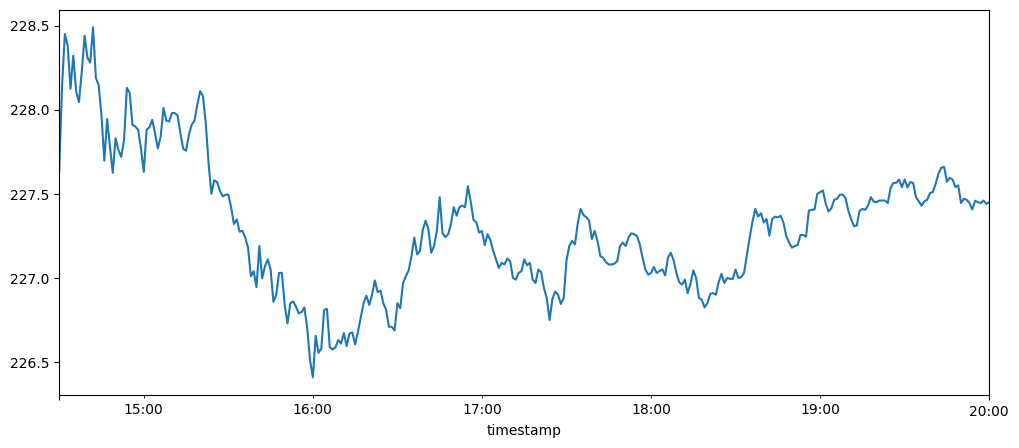

In [4]:
data.close.plot(figsize=(12,5))

### generate feature

In [5]:
from ta import momentum, trend, volatility, volume

In [6]:
def get_ta(df_):
    """
    :param df_: (DataFrame) contain [open,high,low,close,volume] in columns.
    """
    df = df_.copy()   

    df['m_rsi'] = momentum.rsi(df.close)
    df['m_roc'] = momentum.roc(df.close)
    df['m_wr']  = momentum.williams_r(df.high, df.low, df.close)
    df['vm_fi'] = volume.force_index(df.close, df.volume)
    df['vm_eom'] = volume.ease_of_movement(df.high, df.low, df.volume)
    df['vl_bbp'] = volatility.bollinger_pband(df.close)
    df['vl_atr'] = volatility.average_true_range(df.high, df.low, df.close)
    df['t_macdd']  = trend.MACD(df.close).macd_diff()
    df['t_trix'] = trend.trix(df.close)
    df['t_cci'] = trend.cci(df.high, df.low, df.close)
            
    return df 

In [7]:
fea_df = get_ta(data[['volume','open','close','high','low']])

In [8]:
fea_df

,volume,open,close,high,low,m_rsi,m_roc,m_wr,vm_fi,vm_eom,vl_bbp,vl_atr,t_macdd,t_trix,t_cci
timestamp,,,,,,,,,,,,,,,
2024-11-08 14:30:00+00:00,770880,227.1700,227.6400,227.7600,227.1400,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2024-11-08 14:31:00+00:00,237773,227.6400,228.1401,228.1700,227.4700,NaN,NaN,NaN,NaN,108.927422,NaN,0.000000,NaN,NaN,NaN
2024-11-08 14:32:00+00:00,221508,228.1700,228.4501,228.4594,228.0700,NaN,NaN,NaN,NaN,78.176039,NaN,0.000000,NaN,NaN,NaN
2024-11-08 14:33:00+00:00,192968,228.4600,228.3800,228.6600,228.3700,NaN,NaN,NaN,NaN,37.616081,NaN,0.000000,NaN,NaN,NaN
2024-11-08 14:34:00+00:00,155137,228.3700,228.1250,228.3800,228.0000,NaN,NaN,NaN,NaN,-79.607057,NaN,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-08 19:56:00+00:00,26591,227.4535,227.4500,227.4900,227.4301,44.296113,-0.092243,-76.666667,-344.007887,5.732974,0.260787,0.065315,-0.016935,0.000164,-64.940951
2024-11-08 19:57:00+00:00,23227,227.4400,227.4450,227.4500,227.4200,43.781674,-0.055807,-76.785714,-311.454617,-3.235459,0.247178,0.062792,-0.015084,-0.000088,-83.561228
2024-11-08 19:58:00+00:00,23071,227.4450,227.4600,227.4800,227.4300,45.814757,-0.059316,-71.428571,-217.523243,4.334446,0.299002,0.061879,-0.012156,-0.000301,-63.951226


### triple barrier

In [109]:
def add_triple_barrier(prices, events, pt_sl, holding_period):
    """   
    :param prices: (pd.Series) Close prices
    :param events:  (pd.DataFrame): with 't1' (max holding period end time) and 'side' (trade direction).
    :param holding_period: (int) Number of minutes to add for vertical barrier
    """
    
    out = events[['t1']].copy()
    pt, sl = pt_sl
    
    for loc, t1 in events['t1'].fillna(prices.index[-1]).items():
        # Get the price series between the entry time and the barrier time
        price_path = prices[loc:t1]
        
        # Calculate the thresholds
        initial_price = prices[loc]
        upper_barrier = initial_price * (1 + pt)
        lower_barrier = initial_price * (1 - sl)

        # Check if barriers are hit
        hit_upper = price_path[price_path >= upper_barrier]
        hit_lower = price_path[price_path <= lower_barrier]

        # Determine the first barrier touched or exit at holding period
        if not hit_upper.empty:
            out.loc[loc, 'exit'] = hit_upper.index[0]
            out.loc[loc, 'label'] = 1  # Profit
        elif not hit_lower.empty:
            out.loc[loc, 'exit'] = hit_lower.index[0]
            out.loc[loc, 'label'] = -1  # Loss
        else:
            out.loc[loc, 'exit'] = t1
            out.loc[loc, 'label'] = int(prices[t1] > initial_price)  # Outcome based on final price
    
    return out

In [110]:
def meta_labeling(prices, signals, pt_sl, holding_period):
    """
    :param prices: (pd.Series) Close prices
    :signals: (pd.Series) Primary trade signals (1 for Long, -1 for Short)
    :pt_sl: (list) [profit-taking threshold, stop-loss threshold].
    :holding_period: (int) Maximum holding period in minutes.
    """

    # Step 1: Define events
    events = pd.DataFrame(index=signals.index)
    max_t1 = signals.index[-1]
    events['t1'] = signals.index + pd.Timedelta(minutes=holding_period)
    events['t1'] = np.minimum(events['t1'], max_t1)
    events['side'] = signals  # Direction of the trade
    
    # Step 2: Apply triple-barrier method
    outcomes = add_triple_barrier(prices, events, pt_sl, holding_period)
    print(outcomes)

    # Step 3: Create meta-labels
    meta_labels = pd.DataFrame(index=outcomes.index)
    meta_labels['exit'] = outcomes['exit']
    meta_labels['price'] = prices
    meta_labels['primary_signal'] = signals
    meta_labels['meta_label'] = outcomes['label']  # 1 = Successful trade, 0 = Not successful
    return meta_labels

In [111]:
close = data.close

AttributeError: 'DataFrame' object has no attribute 'close'

In [112]:
close

timestamp
2024-11-08 14:30:00+00:00    227.6400
2024-11-08 14:31:00+00:00    228.1401
2024-11-08 14:32:00+00:00    228.4501
2024-11-08 14:33:00+00:00    228.3800
2024-11-08 14:34:00+00:00    228.1250
                               ...   
2024-11-08 19:56:00+00:00    227.4500
2024-11-08 19:57:00+00:00    227.4450
2024-11-08 19:58:00+00:00    227.4600
2024-11-08 19:59:00+00:00    227.4400
2024-11-08 20:00:00+00:00    227.4499
Name: close, Length: 331, dtype: float64

In [117]:
import ta
f_window = 5
s_window = 10

fema = ta.trend.ema_indicator(close,f_window)
sema = ta.trend.ema_indicator(close,s_window)

diffema = fema-sema
diffema = np.sign(diffema.diff()).fillna(0)
diffema

timestamp
2024-11-08 14:30:00+00:00    0.0
2024-11-08 14:31:00+00:00    0.0
2024-11-08 14:32:00+00:00    0.0
2024-11-08 14:33:00+00:00    0.0
2024-11-08 14:34:00+00:00    0.0
                            ... 
2024-11-08 19:56:00+00:00    1.0
2024-11-08 19:57:00+00:00    1.0
2024-11-08 19:58:00+00:00    1.0
2024-11-08 19:59:00+00:00    1.0
2024-11-08 20:00:00+00:00    1.0
Length: 331, dtype: float64

In [118]:
primary_signals = diffema

In [119]:
primary_signals

timestamp
2024-11-08 14:30:00+00:00    0.0
2024-11-08 14:31:00+00:00    0.0
2024-11-08 14:32:00+00:00    0.0
2024-11-08 14:33:00+00:00    0.0
2024-11-08 14:34:00+00:00    0.0
                            ... 
2024-11-08 19:56:00+00:00    1.0
2024-11-08 19:57:00+00:00    1.0
2024-11-08 19:58:00+00:00    1.0
2024-11-08 19:59:00+00:00    1.0
2024-11-08 20:00:00+00:00    1.0
Length: 331, dtype: float64

In [120]:
# Profit-taking: 1%, Stop-loss: 0.5%
pt_sl = [0.05, 0.01] 
holding_period = 20 

In [121]:
meta_labels = meta_labeling(close, primary_signals, pt_sl, holding_period)

                                                 t1                      exit  \
timestamp                                                                       
2024-11-08 14:30:00+00:00 2024-11-08 14:50:00+00:00 2024-11-08 14:50:00+00:00   
2024-11-08 14:31:00+00:00 2024-11-08 14:51:00+00:00 2024-11-08 14:51:00+00:00   
2024-11-08 14:32:00+00:00 2024-11-08 14:52:00+00:00 2024-11-08 14:52:00+00:00   
2024-11-08 14:33:00+00:00 2024-11-08 14:53:00+00:00 2024-11-08 14:53:00+00:00   
2024-11-08 14:34:00+00:00 2024-11-08 14:54:00+00:00 2024-11-08 14:54:00+00:00   
...                                             ...                       ...   
2024-11-08 19:56:00+00:00 2024-11-08 20:00:00+00:00 2024-11-08 20:00:00+00:00   
2024-11-08 19:57:00+00:00 2024-11-08 20:00:00+00:00 2024-11-08 20:00:00+00:00   
2024-11-08 19:58:00+00:00 2024-11-08 20:00:00+00:00 2024-11-08 20:00:00+00:00   
2024-11-08 19:59:00+00:00 2024-11-08 20:00:00+00:00 2024-11-08 20:00:00+00:00   
2024-11-08 20:00:00+00:00 20

In [122]:
meta_labels

,exit,price,primary_signal,meta_label
timestamp,,,,
2024-11-08 14:30:00+00:00,2024-11-08 14:50:00+00:00,227.6400,0.0,1.0
2024-11-08 14:31:00+00:00,2024-11-08 14:51:00+00:00,228.1401,0.0,0.0
2024-11-08 14:32:00+00:00,2024-11-08 14:52:00+00:00,228.4501,0.0,0.0
2024-11-08 14:33:00+00:00,2024-11-08 14:53:00+00:00,228.3800,0.0,0.0
2024-11-08 14:34:00+00:00,2024-11-08 14:54:00+00:00,228.1250,0.0,1.0
...,...,...,...,...
2024-11-08 19:56:00+00:00,2024-11-08 20:00:00+00:00,227.4500,1.0,0.0
2024-11-08 19:57:00+00:00,2024-11-08 20:00:00+00:00,227.4450,1.0,1.0
2024-11-08 19:58:00+00:00,2024-11-08 20:00:00+00:00,227.4600,1.0,0.0


In [123]:
meta_labels.meta_label.value_counts()

meta_label
1.0    167
0.0    164
Name: count, dtype: int64

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [125]:
features = fea_df.iloc[:,5:].dropna(how='any',axis=0)

In [126]:
features

,m_rsi,m_roc,m_wr,vm_fi,vm_eom,vl_bbp,vl_atr,t_macdd,t_trix,t_cci
timestamp,,,,,,,,,,
2024-11-08 15:13:00+00:00,47.762817,-0.008777,-40.350877,435.512668,6.165810,0.389593,0.208562,0.008074,-0.001040,23.643232
2024-11-08 15:14:00+00:00,44.225373,-0.056035,-56.561404,-455.386228,-35.903328,0.195835,0.209372,-0.003243,-0.001011,-51.695547
2024-11-08 15:15:00+00:00,43.798158,-0.080591,-71.000000,-528.725381,-36.377740,0.184462,0.212988,-0.010842,-0.001092,-115.030190
2024-11-08 15:16:00+00:00,48.274411,-0.004257,-51.000000,-6.196327,21.556479,0.446633,0.205982,-0.008969,-0.001161,-43.722270
2024-11-08 15:17:00+00:00,50.946584,0.061466,-38.297872,339.200506,23.348187,0.607031,0.200555,-0.003425,-0.001165,18.294747
...,...,...,...,...,...,...,...,...,...,...
2024-11-08 19:56:00+00:00,44.296113,-0.092243,-76.666667,-344.007887,5.732974,0.260787,0.065315,-0.016935,0.000164,-64.940951
2024-11-08 19:57:00+00:00,43.781674,-0.055807,-76.785714,-311.454617,-3.235459,0.247178,0.062792,-0.015084,-0.000088,-83.561228
2024-11-08 19:58:00+00:00,45.814757,-0.059316,-71.428571,-217.523243,4.334446,0.299002,0.061879,-0.012156,-0.000301,-63.951226


In [127]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
fea_norm = pd.DataFrame(scaler.fit_transform(features),index=features.index)

from sklearn.decomposition import PCA
pca = PCA(10)
features_pca = pd.DataFrame(pca.fit_transform(fea_norm),index=features.index)
features_pca

,0,1,2,3,4,5,6,7,8,9
timestamp,,,,,,,,,,
2024-11-08 15:13:00+00:00,-0.012561,2.006322,0.209503,1.956412,0.155193,-0.321009,-0.137863,-0.190083,-0.299344,0.438926
2024-11-08 15:14:00+00:00,1.748790,1.369934,2.277485,1.811785,0.139410,0.207856,-0.443944,-0.068146,-0.083835,0.323844
2024-11-08 15:15:00+00:00,2.391287,1.176355,2.165379,2.024761,0.277318,0.157151,-0.449510,-0.146317,0.172072,-0.056418
2024-11-08 15:16:00+00:00,0.385376,1.757029,-0.833592,2.181760,-0.043831,-0.738241,-0.289225,-0.043312,0.083935,-0.046513
2024-11-08 15:17:00+00:00,-0.672466,1.900449,-0.764051,1.995704,-0.154703,-0.786687,-0.266971,0.323405,0.089858,-0.002920
...,...,...,...,...,...,...,...,...,...,...
2024-11-08 19:56:00+00:00,1.298106,-1.210493,-0.886302,-0.463623,0.146753,0.071025,0.207488,-0.178863,-0.144372,0.080624
2024-11-08 19:57:00+00:00,1.348226,-1.283624,-0.349453,-0.650061,0.324403,-0.042153,0.014480,-0.010643,-0.074517,-0.003485
2024-11-08 19:58:00+00:00,0.958874,-1.128925,-0.733751,-0.661385,0.230693,-0.008278,0.072109,-0.127943,-0.060183,0.027342


In [128]:
# Join features with meta-labels
df = features_pca.join(meta_labels['meta_label']).dropna()

# Train-test split
X = df.drop('meta_label', axis=1)
y = df['meta_label']
X_train, X_test = X.iloc[:200,:],X.iloc[200:,]
y_train, y_test = y.iloc[:200],y.iloc[200:]

# Train the meta-model
meta_model = RandomForestClassifier(random_state=42)
meta_model.fit(X_train, y_train)

# Evaluate
y_pred = meta_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.34      0.93      0.50        30
         1.0       0.67      0.07      0.12        58

    accuracy                           0.36        88
   macro avg       0.50      0.50      0.31        88
weighted avg       0.56      0.36      0.25        88

